# Instalacão de dependências

In [1]:
!pip install -q pystac-client rasterio pyproj scikit-image matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 5.0 MB/s eta 0:00:00


# Configuração do ambiente e importar bibliotecas

In [2]:
import os

# Habilita os caches do GDAL (Opcional)
os.environ["GDAL_HTTP_MULTIPLEX"] = "YES"
os.environ["GDAL_HTTP_MERGE_CONSECUTIVE_RANGES"] = "YES"

import matplotlib.pyplot as plt
import numpy as np
import pystac_client
import rasterio
from pyproj import Transformer
from rasterio.windows import from_bounds
from skimage.transform import resize

# Início do código

In [3]:
# Criar serviço a partir da URL do STAC-INPE
service = pystac_client.Client.open("https://data.inpe.br/bdc/stac/v1/")

# Bounding box da região de Sinop-MT
bbox_sinop = [-55.62, -11.95, -55.40, -11.78]

# Criar busca no PyStac
item_search = service.search(
    collections=["CB4A-WPM-L4-DN-1"],
    bbox=bbox_sinop,
    datetime="2020-01-01/2020-12-31",
    query={"eo:cloud_cover": {"lt": 10}},
)
itens = list(item_search.items())

# Exibir itens encontrados
for idx, item in enumerate(itens):
    print(f"Index [{idx}] -> ID da Imagem: {item.id}")


Index [0] -> ID da Imagem: CBERS_4A_WPM_20201122_217_128_L4
Index [1] -> ID da Imagem: CBERS_4A_WPM_20201022_217_128_L4
Index [2] -> ID da Imagem: CBERS_4A_WPM_20200921_217_128_L4
Index [3] -> ID da Imagem: CBERS_4A_WPM_20200821_217_128_L4
Index [4] -> ID da Imagem: CBERS_4A_WPM_20200721_217_128_L4
Index [5] -> ID da Imagem: CBERS_4A_WPM_20200620_217_128_L4


In [4]:
# Selecionar o item desejado
item = itens[4]
print(f"Assets: {list(item.assets.keys())}")

Assets: ['BAND0', 'BAND1', 'BAND2', 'BAND3', 'BAND4', 'BAND0_xml', 'BAND1_xml', 'BAND2_xml', 'BAND3_xml', 'BAND4_xml', 'thumbnail']


In [5]:
# Converter bounding box para o SRC da imagem (4326 -> 32721) para recorte
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32721", always_xy=True)
minx, miny = transformer.transform(bbox_sinop[0], bbox_sinop[1])
maxx, maxy = transformer.transform(bbox_sinop[2], bbox_sinop[3])

# Obter recorte da imagem
def get_window(src):
    return (
        from_bounds(minx, miny, maxx, maxy, src.transform)
        .round_offsets()
        .round_lengths()
    )

# Converter para 8 bits, aplicar min-max e brilho
def normalize(array, brightness_factor):
    normalized = (array - array.min()) / (array.max() - array.min())
    return (np.clip(normalized * brightness_factor, 0, 1) * 255).astype(np.uint8)

In [6]:
# Obtem as imagens cortadas para cada banda
with rasterio.open(item.assets["BAND3"].href) as src:
    window = get_window(src)
    red = src.read(1, window=window)

with rasterio.open(item.assets["BAND2"].href) as src:
    green = src.read(1, window=window)

with rasterio.open(item.assets["BAND1"].href) as src:
    blue = src.read(1, window=window)

with rasterio.open(item.assets["BAND0"].href) as src:
    pan_window = get_window(src)
    pan = src.read(1, window=pan_window)

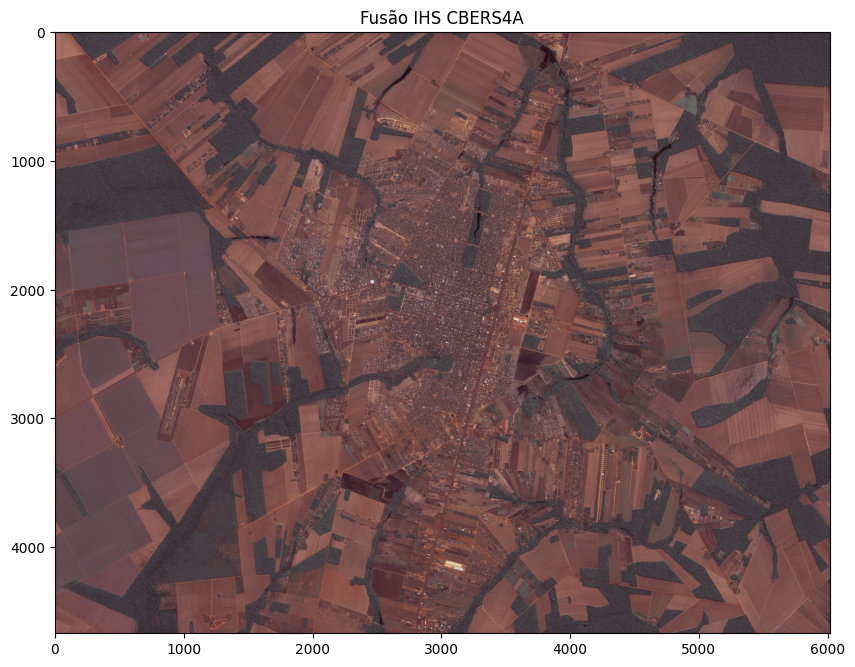

In [7]:
# Interpolar bandas para 4m (bicubico, imita comportamento do TerraView)
target_shape = (pan.shape[0] // 2, pan.shape[1] // 2)
r = resize(red.astype(float), target_shape, order=3)
g = resize(green.astype(float), target_shape, order=3)
b = resize(blue.astype(float), target_shape, order=3)
pan_resized = resize(pan.astype(float), target_shape, order=3)

# Calcular intensidade e delta para as bandas RGB
intensity = (r + g + b) / 3
pan_matched = pan_resized * (intensity.mean() / pan_resized.mean())
delta = pan_matched - intensity

# Aplicar delta para as bandas RGB
r_sharp = r + delta
g_sharp = g + delta
b_sharp = b + delta

# Normalizar e aplicar brilho
brightness_factor = 1
rgb = np.dstack((
    normalize(r_sharp, brightness_factor),
    normalize(g_sharp, brightness_factor),
    normalize(b_sharp, brightness_factor),
))

# Exibir resultado
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Fusão IHS CBERS4A")
plt.savefig("fusao_ihs_cbers4a.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("fusao_ihs_cbers4a.png")